# 可选实验——多类别分类

## 1.1 目标
在本实验中，你将探索使用神经网络进行多类别分类的示例。
<figure>
 <img src="../work/images/C2_W2_mclass_header.png"   style="width500px;height:200px;">
</figure>

## 1.2 工具
您将使用一些绘图例程。它们存储在本目录的 `lab_utils_multiclass_TF.py` 中。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
from sklearn.datasets import make_blobs
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
np.set_printoptions(precision=2)
from lab_utils_multiclass_TF import *
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

# 2.0 多分类
神经网络常用于对数据进行分类。例如，神经网络可以：
- 接收照片，并将照片中的主体分类为 {狗、猫、马、其他}
- 接收一个句子，并对其中元素的“词性”进行分类：{名词、动词、形容词等}

这种类型的网络在最后一层会有多个单元。每个输出都与一个类别关联。将一个输入样本输入网络后，输出值最高的类别就是预测类别。如果将输出应用于 softmax 函数，则 softmax 的输出将提供输入属于各类别的概率。

在本实验中，你将看到一个使用 TensorFlow 构建多分类网络的示例。然后，我们将了解神经网络如何进行预测。

让我们从创建一个四分类数据集开始。

## 2.1 准备并可视化数据
我们将使用 Scikit-Learn 的 `make_blobs` 函数创建一个包含 4 个类别的训练数据集，如下图所示。

In [2]:
# make 4-class dataset for classification
classes = 4
m = 100
centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]
std = 1.0
X_train, y_train = make_blobs(n_samples=m, centers=centers, cluster_std=std,random_state=30)

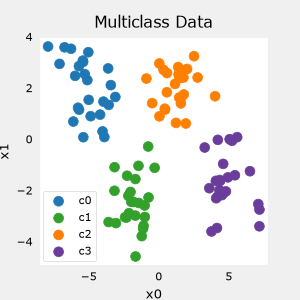

In [3]:
plt_mc(X_train,y_train,classes, centers, std=std)

每个点表示一个训练样本。坐标轴 (x0,x1) 是输入，颜色表示样本所属的类别。模型训练完成后，会接收一个新样本 (x0,x1)，并预测其类别。

尽管该数据集是生成的，但它能够代表许多现实世界中的分类问题。这些问题具有多个输入特征 (x0,...,xn) 和多个输出类别。模型经过训练，使用输入特征预测正确的输出类别。

In [4]:
# show classes in data set
print(f"unique classes {np.unique(y_train)}")
# show how classes are represented
print(f"class representation {y_train[:10]}")
# show shapes of our dataset
print(f"shape of X_train: {X_train.shape}, shape of y_train: {y_train.shape}")

unique classes [0 1 2 3]
class representation [3 3 3 0 3 3 3 3 2 0]
shape of X_train: (100, 2), shape of y_train: (100,)


## 2.2 模型
<img align="Right" src="../work/images/C2_W2_mclass_lab_network.PNG"  style=" width:350px; padding: 10px 20px ; ">
本实验将使用如图所示的两层网络。
与二分类网络不同，该网络有四个输出，每个类别对应一个输出。给定一个输入样本，值最大的输出就是对该输入的预测类别。

下面给出了如何在 TensorFlow 中构建该网络的示例。请注意，输出层使用的是 `linear`，而不是 `softmax` 激活函数。虽然可以在输出层中加入 softmax，但如果在训练期间将线性输出传递给损失函数，数值稳定性会更好。如果使用模型预测概率，则可以在此时应用 softmax。

In [5]:
tf.random.set_seed(1234)  # applied to achieve consistent results
model = Sequential(
    [
        Dense(2, activation = 'relu',   name = "L1"),
        Dense(4, activation = 'linear', name = "L2")
    ]
)

下面的语句会编译并训练网络。将 `from_logits=True` 设为损失函数的参数，表示输出激活为线性激活，而不是 softmax。

In [6]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)

model.fit(
    X_train,y_train,
    epochs=200
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.8579  
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.6958 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.5572 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.4307 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.3154 
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2110 
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1177 
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0351 
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9627 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8997 
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8446 
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7963 
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7534 
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7148 
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6796 
Epoch 16/200
4/4 ━

模型训练完成后，我们可以查看模型如何对训练数据进行分类。

184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


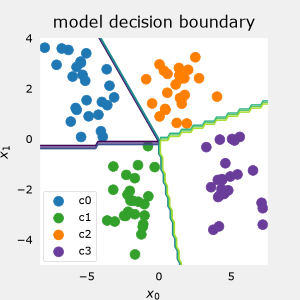

In [7]:
plt_cat_mc(X_train, y_train, model, classes)

上面的决策边界展示了模型如何划分输入空间。这个非常简单的模型轻松完成了训练数据的分类。它是如何做到的？让我们更详细地观察网络。

下面，我们将从模型中提取训练后的权重，并用它绘制各网络单元的函数。再往下会有对结果更详细的说明。你不需要了解这些细节也能成功使用神经网络，但它们可能有助于你更直观地理解各层如何组合起来解决分类问题。

In [8]:
# gather the trained parameters from the first layer
l1 = model.get_layer("L1")
W1,b1 = l1.get_weights()

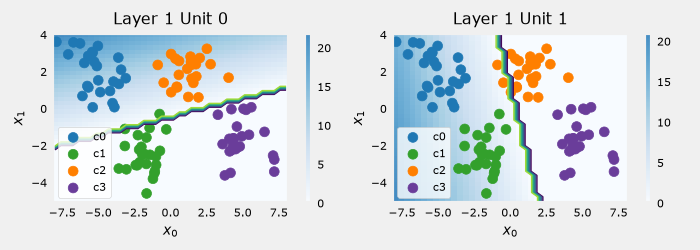

In [9]:
# plot the function of the first layer
plt_layer_relu(X_train, y_train.reshape(-1,), W1, b1, classes)

In [16]:
# gather the trained parameters from the output layer
l2 = model.get_layer("L2")
W2, b2 = l2.get_weights()
# create the 'new features', the training examples after L1 transformation
Xl2 = np.zeros_like(X_train)
Xl2 = np.maximum(0, np.dot(X_train,W1) + b1)

plt_output_layer_linear(Xl2, y_train.reshape(-1,), W2, b2, classes,
                        x0_rng = (-0.25,np.amax(Xl2[:,0])), x1_rng = (-0.25,np.amax(Xl2[:,1])))

ValueError: 
$a^{[1]}_1$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

## 说明
#### 第 1 层 <img align="Right" src="../work/images/C2_W2_mclass_layer1.png"  style=" width:600px; padding: 10px 20px ; ">
这些图展示了网络第一层中单元 0 和单元 1 的函数。坐标轴上的输入为（$x_0,x_1$）。单元的输出由背景颜色表示，每张图右侧的颜色条对此进行了说明。请注意，由于这些单元使用 ReLU，其输出不一定介于 0 和 1 之间；在本例中，峰值大于 20。
该图中的等高线显示了输出 $a^{[1]}_j$ 从零到非零的过渡点。回顾 ReLU 的图像：<img align="right" src="../work/images/C2_W2_mclass_relu.png"  style=" width:200px; padding: 10px 20px ; "> 图中的等高线就是 ReLU 的拐点。

单元 0 将类别 0 和 1 与类别 2 和 3 分开。直线左侧的点（类别 0 和 1）将输出零，而右侧的点将输出大于零的值。  
单元 1 将类别 0 和 2 与类别 1 和 3 分开。直线上方的点（类别 0 和 2）将输出零，而下方的点将输出大于零的值。让我们看看这在下一层中如何发挥作用！

#### 第 2 层：输出层 <img align="Right" src="../work/images/C2_W2_mclass_layer2.png"  style=" width:600px; padding: 10px 20px ; ">

这些图中的点是经过第一层变换后的训练样本。可以这样理解：第一层创建了一组新特征，供第二层评估。这些图的坐标轴是前一层的输出 $a^{[1]}_0$ 和 $a^{[1]}_1$。正如上面所预测的，类别 0 和 1（绿色和蓝色）具有 $a^{[1]}_0 = 0$，而类别 1 和 2（蓝色和绿色）具有 $a^{[1]}_1 = 0$。  
背景颜色的深浅仍然表示最大值的大小。  
单元 0 在接近 (0,0) 的位置产生最大值，类别 0（蓝色）被映射到这里。  
单元 1 在左上角产生最大值，从而选中类别 1（绿色）。  
单元 2 针对类别 3（橙色）所在的右下角。  
单元 3 在右上角产生最大值，选中最后一个类别（紫色）。  

图中不容易看出的另一个方面是，各单元之间的数值已经协调一致。一个单元仅为它要选择的类别产生最大值还不够；对于该类别中的点，它的值还必须高于所有其他单元。这由损失函数（`SparseCategoricalCrossEntropy`）中隐含的 softmax 函数完成。与其他激活函数不同，softmax 会跨所有输出工作。

即使不了解每个单元具体在做什么，也能成功使用神经网络。希望这个示例能帮助您直观理解其内部发生的过程。

## 恭喜！
你已经学会构建并运行用于多分类的神经网络。